In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/neurocipher/kmeans-clustering-2d-dataset/dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/neurocipher/kmeans-clustering-2d-dataset/dataset.csv')
df.head()

,x,y
0,0.496714,4.861736
1,0.647689,6.523030
2,-0.234153,4.765863
3,1.579213,5.767435
4,-0.469474,5.542560


In [3]:
print(df.info())
print(df.shape)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       150 non-null    float64
 1   y       150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB
None
(150, 2)
                x           y
count  150.000000  150.000000
mean    -0.083223    1.730307
std      2.612546    2.473526
min     -4.839943   -3.158555
25%     -2.366776   -0.237809
50%     -0.053918    0.832002
75%      2.281063    4.417004
max      5.037727    6.852278


## Step 1 → Scatterplot (Raw Data)

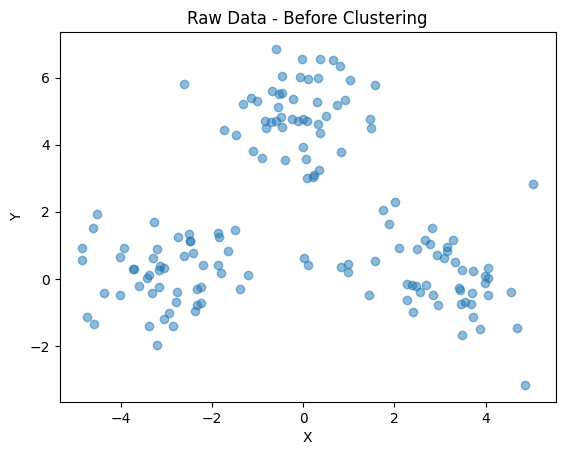

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df['x'], df['y'], alpha=0.5)
plt.title("Raw Data - Before Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## Step 2 → Elbow Method (WCSS plot) and Silhouette Score

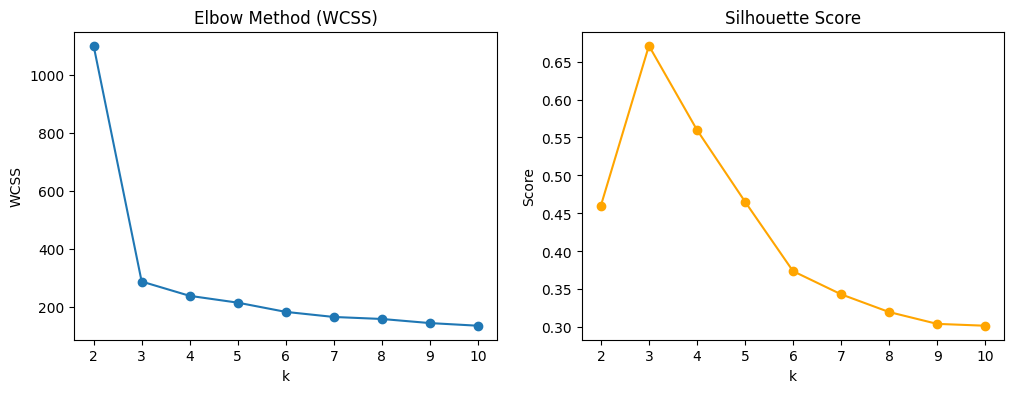

In [8]:
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []

for k in range(2, 11):  # Silhouette k=1 pe defined nahi hota!
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df[['x', 'y']])
    
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df[['x', 'y']], labels))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(2, 11), wcss, marker='o')
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("k")
ax1.set_ylabel("WCSS")

ax2.plot(range(2, 11), silhouette_scores, marker='o', color='orange')
ax2.set_title("Silhouette Score")
ax2.set_xlabel("k")
ax2.set_ylabel("Score")

plt.show()

## Step 3 → Fit K-Means on chosen k.

In [10]:

km = KMeans(n_clusters=3, random_state=42)
df['cluster'] = km.fit_predict(df[['x', 'y']])

## Step 4 → Final Scatterplot (Clusters coloured + Centroids)

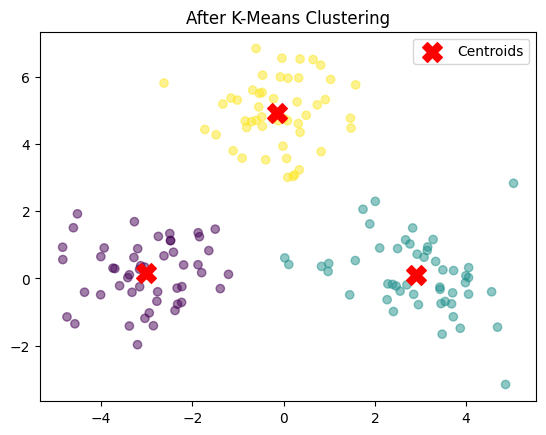

In [11]:
plt.scatter(df['x'], df['y'], c=df['cluster'], cmap='viridis', alpha=0.5)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title("After K-Means Clustering")
plt.legend()
plt.show()

## Step 5 → Cluster Analysis

In [12]:
df['cluster'] = km.labels_
df.groupby('cluster').mean()

,x,y
cluster,,
0,-3.014646,0.162521
1,2.900653,0.100417
2,-0.135676,4.927983


In [13]:
df['cluster'].value_counts()

cluster
2    50
0    50
1    50
Name: count, dtype: int64

## Summary

Dataset         : 2D Synthetic
Total Points    : 150
Best K          : 3
Clusters        : Perfectly balanced (50-50-50) ✅

* Cluster 0 → Left   (x=-3.01, y=0.16)  — 50 points
* Cluster 1 → Right  (x= 2.90, y=0.10)  — 50 points  
* Cluster 2 → Top    (x=-0.13, y=4.92)  — 50 points